In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import os

In [3]:
# Set paths
dataset_path = 'D:\Internship Project\Animal Classification\dataset'  # 🔁 Change this to your dataset folder
img_size = (224, 224)
batch_size = 32
num_classes = 15  # We have 15 animal classes

In [4]:
# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% training, 20% validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [5]:

# Train and Validation Generators
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)


Found 1561 images belonging to 15 classes.


In [6]:
val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 383 images belonging to 15 classes.


In [7]:
# ✅ Load MobileNetV2 without the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers

In [14]:

# Pyramid model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')  # Output Layer
])

In [15]:

# 🔧 Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# 🏋️ Train the model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 408ms/step - accuracy: 0.0694 - loss: 2.8762 - val_accuracy: 0.2585 - val_loss: 2.5891
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 728ms/step - accuracy: 0.1437 - loss: 2.6048 - val_accuracy: 0.4517 - val_loss: 2.4119
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.2326 - loss: 2.4275 - val_accuracy: 0.5796 - val_loss: 2.0833
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3710 - loss: 2.1350 - val_accuracy: 0.6527 - val_loss: 1.6526
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4135 - loss: 1.8872 - val_accuracy: 0.6945 - val_loss: 1.3199
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 78s 974ms/step - accuracy: 0.5335 - loss: 1.5812 - val_accuracy: 0.6997 - val_loss: 1.1198
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 48s 978ms/step - accuracy: 0.5813 - loss: 1.3856 - val_accuracy: 0.7441 - val_loss: 0.9933
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6254 - loss: 1.2268 - val_accuracy: 0.796

In [11]:
# 💾 Save the model
model.save("animal_classifier_model.h5")

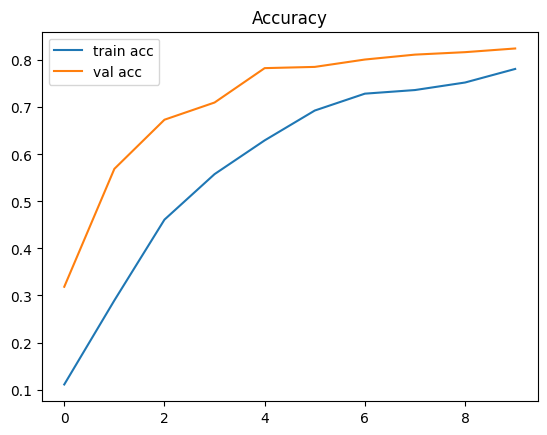

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()
plt.show()


In [13]:
import json

# Save class indices for later use in prediction
with open("class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)
